## Here we compare the our analytic found formulas with their numerical values 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from spike_lib import TwoSpikes
from scipy.optimize import fsolve

### 1rst Part: eigenvalues and eigenvectors of our signal

For our signals $x_1$ and $x_2$, we have defined the observation $Y = \alpha  Y_1 + \sqrt{1-\alpha^2}  Y_2$ with $Y_i \, = \, \lambda _i  x_i  x_i^T +  Z_i$.

Here we consider our observation without noise and analyse $P := a x_1 x_1 ^T + b x_2 x_2^T$ where $a = \alpha \lambda_1$ and $b =  \sqrt{1-\alpha^2} \lambda_2$.

In this part we will compare the analytical and numerical solutions of the eigenvectors and eigenvalues of $P$.

In [ ]:

alpha=np.sqrt(0.5)

N = 1000
rho = 0.2
lam1 = 2
lam2 = 3 
M = 2
LAM1 = np.zeros(M)
LAM2 = np.zeros(M)
m1 = np.zeros(M)
m2 = np.zeros(M)

for m in range(M):

    S = TwoSpikes(N, lam1, lam2, rho)
    
    eigenvalues, eigenvectors =  S.eigen_P()

    LAM1[m] = eigenvalues[0]
    LAM2[m] = eigenvalues[1]
    v1_t = eigenvectors[:, 0]
    v2_t = eigenvectors[:, 1]

    v1, v2 = S.theory_vp()

    m1[m] = abs(np.dot(v1, v1_t)/(np.linalg.norm(v1)*np.linalg.norm(v1_t)))
    m2[m] = abs(np.dot(v2, v2_t)/(np.linalg.norm(v2)*np.linalg.norm(v2_t)))

l1, l2 = S.theory_eig()
print("Eigenvalues:", f"{LAM1.mean():.2f} +- {np.std(LAM1):.2f}", f"{LAM2.mean():.2f} +- {np.std(LAM2):.2f}")  # Print the two largest eigenvalues
print("Theoretical Eigenvalues:", f"{l1:.2f} ", f"{l2:.2f} ")  # Print the theoretical eigenvalues
print("Eigenvector overlaps:", f"{m1.mean():.2f} +- {np.std(m1):.2f}", f"{m2.mean():.2f} +- {np.std(m2):.2f}")  # Print the overlaps of the eigenvectors with the theoretical ones

Eigenvalues: 1.43 +- 0.00 0.13 +- 0.00
Theoretical Eigenvalues: 2.26  -0.71 
Eigenvector overlaps: 0.99 +- 0.00 0.52 +- 0.00


In [ ]:

def theory_eig(a, b, rho):
        """Compute the theoretical eigenvalues of the matrix P."""
        lam1 = (a+b)/2 + np.sqrt((a-b)**2/4 + a*b*rho**2)
        lam2 = (a+b)/2 - np.sqrt((a-b)**2/4 + a*b*rho**2)
        # lam = (a+b)/2 +- sqrt((a-b)^2 /4 + ab rho^2)
        return lam1, lam2



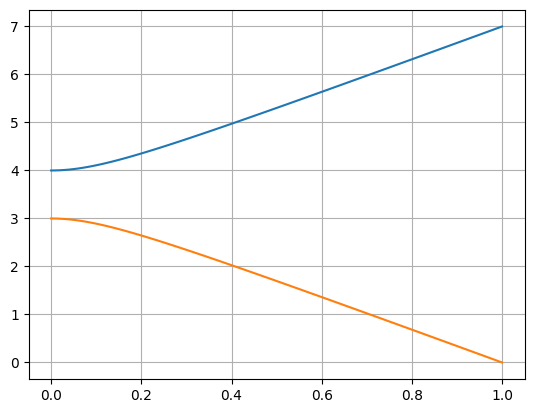

In [11]:
#Plot theory eigenval vs rho
a = 4
b = 3

RHO = np.linspace(0, 1, 100)
lam1, lam2 = theory_eig(a, b, RHO)
plt.plot(RHO, lam1, label='lam1')
plt.plot(RHO, lam2, label='lam2') 

plt.grid()  
plt.show()



In [6]:
def theta_pm(a, b, rho):
    d = np.sqrt((a - b) ** 2 / 4 + a * b * rho**2)
    return (a + b) / 2 + d, (a + b) / 2 - d

def rplus(theta, b, rho):
    r = (theta - b)/(b*rho)
    return r

def c2(theta, b, rho):
    r = rplus(theta, b, rho)
    c = 1/np.sqrt(r**2 + 2*rho*r +1)
    return c 

def eq(a, b, rho, m):
    theta = theta_pm(a, b, rho)[0]
    c = c2(theta, b, rho)
    diff = np.sqrt(1 - theta**(-2))*theta* abs(c)/b - m
    return diff

C:\Users\celia\AppData\Local\Temp\ipykernel_36540\1770155799.py:17: RuntimeWarning: invalid value encountered in sqrt
  diff = np.sqrt(1 - theta**(-2))*theta* abs(c)/b - m
C:\Users\celia\AppData\Local\Temp\ipykernel_36540\4181453397.py:7: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  rho_sol = fsolve(lambda rho: eq(a, b, rho, m), x0=0.5)[0]


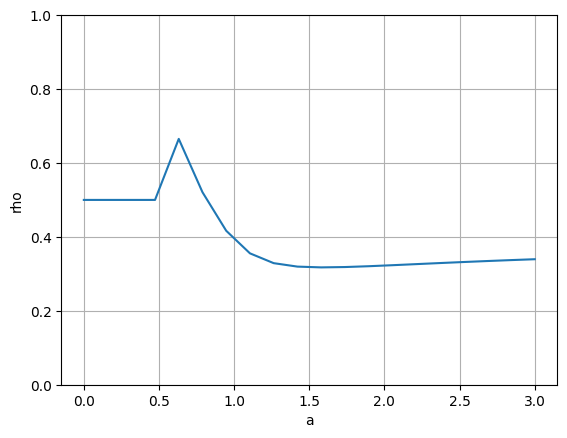

In [33]:
A = np.linspace(0, 3, 20)
b = 0.7
m = 0.4

RHO = []
for a in A:     
    rho_sol = fsolve(lambda rho: eq(a, b, rho, m), x0=0.5)[0]
    RHO.append(rho_sol)


plt.plot(A,RHO)
plt.xlabel("a")
plt.ylabel("rho")
plt.ylim([0,1])
plt.grid()
plt.show()


In [ ]:
def mu_equilibrium(lambda1, lambda2):
    """Reference value mu_eq = lambda2 / (2 (1 - lambda1)^2)."""
    return lambda2 / (2 * (1 - lambda1) ** 2)

def comparison2D(vary_param1, values1, vary_param2, values2,
                  N, lambda1, lambda2, rho, mu,
                  M=20, method=("A", "B"), optimal_mu=False):
    """Sweep two parameters and measure the recovery quality of each method.

    Parameters
    ----------
    vary_param1, vary_param2 : str
        Paramètres balayés, parmi {"N", "lambda1", "lambda2", "rho", "mu"}.
    values1, values2 : iterable
        Valeurs prises par vary_param1 (axe 0) et vary_param2 (axe 1).
    N, lambda1, lambda2, rho, mu : floats
        Valeurs par défaut des paramètres (celles balayées sont écrasées).
    M : int
        Nombre de tirages indépendants par point (pour la moyenne).
    method : sequence of str
        Sous-ensemble de {"A", "B", "naive"} à évaluer.
    optimal_mu : bool
        Si mu n'est pas balayé : True -> cross-validation de mu à chaque
        point, False -> valeur d'équilibre mu_eq.

    Returns
    -------
    dict avec "values1", "values2" (1D), et par méthode m les tableaux 2D
    (shape (len(values1), len(values2))) :
        f"{m}_overlap1", f"{m}_overlap2"
    (moyennes sur M tirages, pas de std).
    """
    if isinstance(method, str):
        method = [method]
    else:
        method = list(method)

    values1 = np.asarray(values1, dtype=float)
    values2 = np.asarray(values2, dtype=float)

    out = {"values1": values1, "values2": values2}

    shape = (len(values1), len(values2))
    grids = {m: {"o1": np.zeros(shape), "o2": np.zeros(shape)} for m in method}

    for i, v1 in enumerate(values1):
        for j, v2 in enumerate(values2):
            params = {"N": N, "lambda1": lambda1, "lambda2": lambda2,
                      "rho": rho, "mu": mu}
            params[vary_param1] = v1
            params[vary_param2] = v2

            # choix de mu s'il n'est balayé sur aucun des deux axes
            if vary_param1 != "mu" and vary_param2 != "mu":
                mu_eq = mu_equilibrium(params["lambda1"], params["lambda2"])
                if optimal_mu:
                    MU = np.linspace(mu_eq - mu_eq / 10, mu_eq + mu_eq / 10, 15)
                    params["mu"], _, _ = cv_mu(
                        MU, int(params["N"]), params["rho"],
                        params["lambda1"], params["lambda2"], M=M, method="A")
                else:
                    params["mu"] = mu_eq

            runs = {m: {"o1": [], "o2": []} for m in method}
            for _ in range(M):
                S = TwoSpikes(int(params["N"]), params["lambda1"],
                              params["lambda2"], params["rho"], params["mu"])
                S.compute_method(method)
                for m in method:
                    o1, o2 = S.overlaps(m)
                    runs[m]["o1"].append(o1)
                    runs[m]["o2"].append(o2)

            for m in method:
                grids[m]["o1"][i, j] = np.mean(runs[m]["o1"])
                grids[m]["o2"][i, j] = np.mean(runs[m]["o2"])

    for m in method:
        out[f"{m}_overlap1"] = grids[m]["o1"]
        out[f"{m}_overlap2"] = grids[m]["o2"]

    return out


def plot_comparison2D(result, vary_param1, vary_param2, method=("A", "B"),
                       functions=None, cmap="viridis", vmin=0, vmax=1,
                       figsize=(11, 4.5)):
    """Plot the colormaps produced by comparison2D.

    Une figure par méthode, avec deux sous-plots (overlap1, overlap2).
    Superpose par-dessus les courbes param2 = f(param1) fournies.

    Parameters
    ----------
    result : dict
        Sortie de comparison2D.
    vary_param1, vary_param2 : str
        Noms des paramètres balayés (pour les labels des axes).
    method : sequence of str
        Méthodes à afficher (doivent être présentes dans result).
    functions : list of (callable, str, dict) or None
        Chaque élément est (f, label, plot_kwargs) où f prend un array
        de valeurs de param1 et renvoie les valeurs correspondantes de
        param2 (forme exacte param2 = f(param1)). plot_kwargs est un
        dict optionnel passé à ax.plot (couleur, style, etc.).
    cmap, vmin, vmax : passés à pcolormesh.
    figsize : taille de chaque figure.
    """
    values1 = result["values1"]
    values2 = result["values2"]
    figs = {}
    if isinstance(method, str):
        method = [method]
    else:
        method = list(method)
        
    for m in method:
        fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
        for ax, key, title in zip(axes,
                                   [f"{m}_overlap1", f"{m}_overlap2"],
                                   ["overlap 1", "overlap 2"]):
            Z = result[key]  # shape (len(values1), len(values2))
            pc = ax.pcolormesh(values2, values1, Z, shading="auto",
                                cmap=cmap, vmin=vmin, vmax=vmax)
            fig.colorbar(pc, ax=ax, label=title)
            ax.set_xlabel(vary_param2)
            ax.set_ylabel(vary_param1)
            ax.set_title(f"Method {m} — {title}")
            ax.set_ylim(values1[0],values1[-1])

            if functions is not None:
                for item in functions:
                    f_or_x, y_or_label, *rest = item
                    if callable(f_or_x):
                        label = rest[0] if rest else ""
                        kwargs = rest[1] if len(rest) > 1 else {}
                        x_plot = values1
                        y_plot = f_or_x(values1)
                    else:
                        # f_or_x = x_array (param2), y_or_label = y_array (param1)
                        x_plot = f_or_x
                        y_plot = y_or_label
                        label = rest[0] if rest else ""
                        kwargs = rest[1] if len(rest) > 1 else {}
                    kwargs = dict(kwargs) if kwargs else {}
                    kwargs.setdefault("color", "white")
                    kwargs.setdefault("lw", 2)
                    ax.plot(x_plot, y_plot, label=label, **kwargs)
                ax.legend(loc="best", fontsize=8)

        fig.suptitle(f"Method {m}")
        figs[m] = fig

    return figs

C:\Users\celia\AppData\Local\Temp\ipykernel_36540\1770155799.py:17: RuntimeWarning: invalid value encountered in sqrt
  diff = np.sqrt(1 - theta**(-2))*theta* abs(c)/b - m
C:\Users\celia\AppData\Local\Temp\ipykernel_36540\3452334332.py:21: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  rho_1 = fsolve(lambda rho: eq(a, b, rho, m), x0=0.5)[0]
C:\Users\celia\AppData\Local\Temp\ipykernel_36540\3452334332.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  rho_2 = fsolve(lambda rho: theta_pm(a, b, rho)[0] - 1, x0=0.5)[0]
C:\Users\celia\AppData\Local\Temp\ipykernel_36540\3452334332.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  rho_2 = fsolve(lambda rho: theta_pm(a, b, rho)[0] - 1, x0=0.5)[0]


{'naive': <Figure size 1100x450 with 4 Axes>}

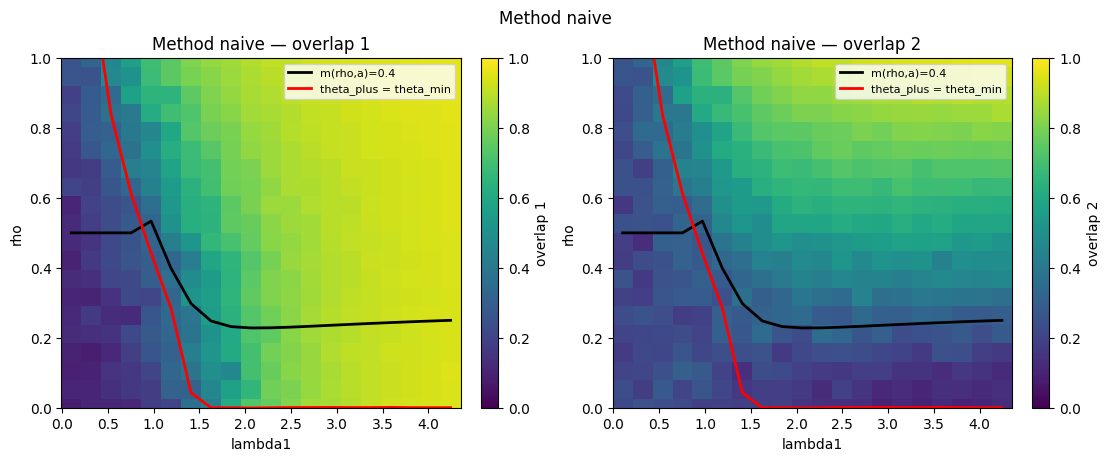

In [ ]:
alpha=np.sqrt(0.5)
N=100
A = np.linspace(0.1*alpha, 3, 20)
RHO = np.linspace(0,1,20)
b = 0.7
m = 0.3
LAM1 = A/alpha
lambda1 = 2
lambda2 = b/np.sqrt(1-alpha**2)
rho = 1
vary_param1, values1, vary_param2, values2 = "rho", RHO, "lambda1", LAM1

def theta_pm(a, b, rho):
    d = np.sqrt((a - b) ** 2 / 4 + a * b * rho**2)
    return (a + b) / 2 + d, (a + b) / 2 - d

f1 = []
f2 = []
 
for a in A:     
    rho_1 = fsolve(lambda rho: eq(a, b, rho, m), x0=0.5)[0]
    rho_2 = fsolve(lambda rho: theta_pm(a, b, rho)[0] - 1, x0=0.5)[0]
    f1.append(rho_1)
    f2.append(rho_2)

out = comparison2D(vary_param1, values1, vary_param2, values2,
                  N, lambda1, lambda2, rho, mu=1,
                  M=20, method="naive", optimal_mu=False)


funct1 = [LAM1, f1, "m(rho,a)=0.4", {"color": "k"}]
funct2 = [LAM1, f2, "theta_plus = theta_min", {"color": "r"}]

function = [funct1, funct2]

plot_comparison2D(out, vary_param1, vary_param2, method="naive",
                       functions=function, cmap="viridis", vmin=0, vmax=1,
                       figsize=(11, 4.5))

{'naive': <Figure size 1100x450 with 4 Axes>}

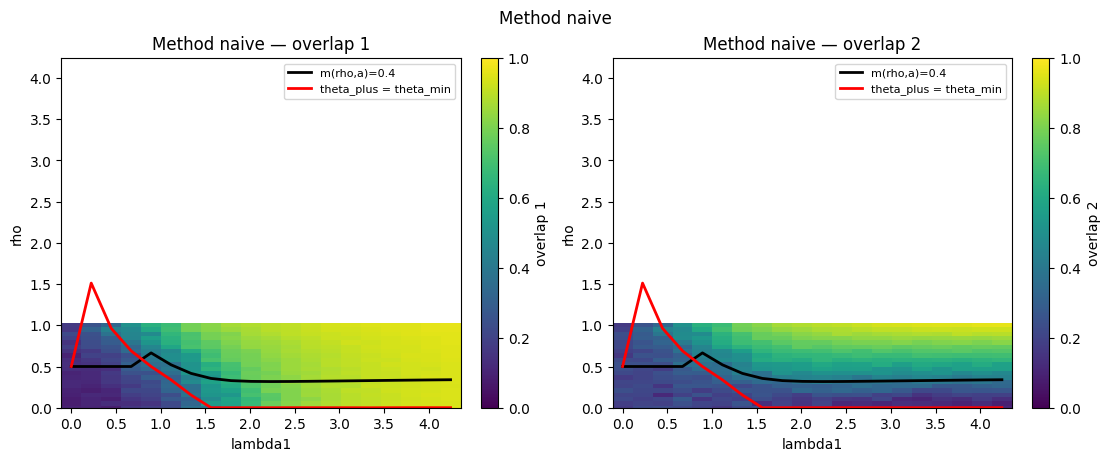

In [70]:



plot_comparison2D(out, vary_param1, vary_param2, method="naive",
                       functions=function, cmap="viridis", vmin=0, vmax=1,
                       figsize=(11, 4.5))